<a href="https://colab.research.google.com/github/SarthakGupta345/PytorchLearning/blob/main/langraphfirst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Hello wordl")
!pip install -qU langgraph langchain  langchain-groq

Hello wordl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.0 MB/s eta 0:00:00


In [2]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [32]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=60,
    reasoning_format="parsed",
    timeout=None,
    max_retries=1,
)

In [33]:
response = llm.invoke("capital of india")
print(response.content)

The capital of India is **New Delhi**.


In [34]:
from typing import TypedDict,List,Annotated
from langgraph.graph import StateGraph,START,END
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.messages import HumanMessage,AIMessage
from langchain_core.runnables.graph import MermaidDrawMethod


In [35]:
class State(TypedDict):
  text:str
  classification:str
  entities:List[str]
  summary:str




In [36]:
def classification_node(state: State):
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Classify the following text into one of the categories: News, Blog, Research, or Other.\n\nText:{text}\n\nCategory:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    classification = llm.invoke([message]).content.strip()
    return {"classification": classification}

In [37]:
def entity_extraction_node(state: State):
    '''Extract all the entities (Person, Organization, Location) from the text'''
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Extract all the entities (Person, Organization, Location) from the following text. Provide the result as a comma-separated list.\n\nText:{text}\n\nEntities:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    entities = llm.invoke([message]).content.strip().split(", ")
    return {"entities": entities}

In [38]:
def summarization_node(state: State):
    '''Summarize the text in one short sentence'''
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Summarize the following text in one short sentence.\n\nText:{text}\n\nSummary:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    summary = llm.invoke([message]).content.strip()
    return {"summary": summary}

In [39]:

# Create our StateGraph
workflow = StateGraph(State)

# Add nodes to the graph
workflow.add_node("classification_node", classification_node)
workflow.add_node("entity_extraction", entity_extraction_node)
workflow.add_node("summarization", summarization_node)

# Add edges to the graph
workflow.set_entry_point("classification_node")  # Set the entry point of the graph
workflow.add_edge("classification_node", "entity_extraction")
workflow.add_edge("entity_extraction", "summarization")
workflow.add_edge("summarization", END)

# Compile the graph
app = workflow.compile()

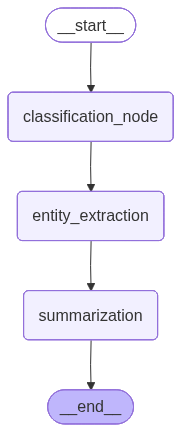

In [40]:
app

In [41]:

sample_text =  """
The recent advancements in quantum computing have opened new possibilities for cryptography and data security.
Researchers at MIT and Google have demonstrated quantum algorithms that could potentially break current encryption methods.
However, they are also developing new quantum-resistant encryption techniques to protect data in the future.
"""



state_input = {"text": sample_text}
result = app.invoke(state_input)

print("Classification:", result["classification"])
print("\nEntities:", result["entities"])
print("\nSummary:", result["summary"])

Classification: 

Entities: ['']

Summary: Recent quantum computing breakthroughs threaten current encryption but also inspire the development of quantum‑resistant security methods.


In [42]:
class EnhancedState(TypedDict):
  text:str
  classification:str
  entities:List[str]
  summary:str
  sentiment:str

In [43]:
def route_after_classification(state:State)->str:
  category = state['classification'].lower()
  return category in ['news','blog','research']

In [44]:
def sentiment_node(state: EnhancedState):
    '''Analyze the sentiment of the text: Positive, Negative, or Neutral'''
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Analyze the sentiment of the following text. Is it Positive, Negative, or Neutral?\n\nText:{text}\n\nSentiment:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    sentiment = llm.invoke([message]).content.strip()
    return {"sentiment": sentiment}


In [48]:
from langgraph.graph import StateGraph,END,START
conditional_workflows = StateGraph(EnhancedState)

# Add nodes to the graph
conditional_workflows.add_node("classification_node", classification_node)
conditional_workflows.add_node("entity_extraction", entity_extraction_node)
conditional_workflows.add_node("summarization", summarization_node)
conditional_workflows.add_node("sentiment_analysis", sentiment_node)

# Add edges
conditional_workflows.add_edge(START,"classification_node")
conditional_workflows.add_conditional_edges("classification_node",route_after_classification,path_map={
    True:["entity_extraction","sentiment_analysis"],
    False:["summarization"]
})
conditional_workflows.add_edge("entity_extraction", "summarization")
conditional_workflows.add_edge("summarization","sentiment_analysis")
conditional_workflows.add_edge("sentiment_analysis",END)

In [49]:
final_graph = conditional_workflows.compile()

TypeError: unhashable type: 'list'